# Método de Gauss-Seidel.

**Objetivo.** 

Describir e implementar el algoritmo de Gauss-Seidel para la solución de sistemas de ecuaciones lineales.


**Trabajo realizado con el apoyo del Programa UNAM-DGAPA-PAPIME, proyectos PE101019, PE101922 y PE106025.**

[![License: CC BY-SA 4.0](https://img.shields.io/badge/License-CC_BY--SA_4.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)

<div class="alert alert-danger">

**Ojo**. Ejecuta la siguiente celda para que todo lo que sigue funcione correctamente.
</div>

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid") 
import dfsol

# Planteamiento.

Supongamos el siguiente sistema de ecuaciones lineales:

$$
\left(
\begin{array}{cc}
-2 & 1 \\
1 & -2
\end{array} \right)
\left(
\begin{array}{c}
x \\
y
\end{array} \right) =
-\left(
\begin{array}{c}
638.89 \\ 
238.89
\end{array} \right) \tag{1}
$$

Este sistema se puede escribir en términos de las siguientes ecuaciones:

$$
\begin{array}{ccc}
y & = &2x - 638.89 \\
y & = & \dfrac{x}{2} + 119.44 
\end{array}
$$

y de acuerdo con la ecuación general de la línea recta $y = mx + b$ tenemos que:
* Para la primera ecuación : $m_1 = 2$ y $b_1 = -638.89$.
* Para la segunda ecuación: $m_1 = \frac{1}{2}$ y $b_2 = 119.44$ .

Con estas definiciones de la recta se puede hacer una gráfica como sigue:

<div class="alert alert-info">

## Ejemplo 1.

En la siguiente celda definimos $m_1$, $b_1$, $m_2$, $b_2$, evaluamos las dos ecuaciones de la recta en el intervalo $x \in [100,800]$, y luego graficamos ambas rectas.

</div>

x = [100. 170. 240. 310. 380. 450. 520. 590. 660. 730. 800.]

m1 = 2
b1 = -638.89
y1 = [-438.89 -298.89 -158.89  -18.89  121.11  261.11  401.11  541.11  681.11
  821.11  961.11]

m2 = 0.5
b2 = 119.44
y2 = [169.44 204.44 239.44 274.44 309.44 344.44 379.44 414.44 449.44 484.44
 519.44]


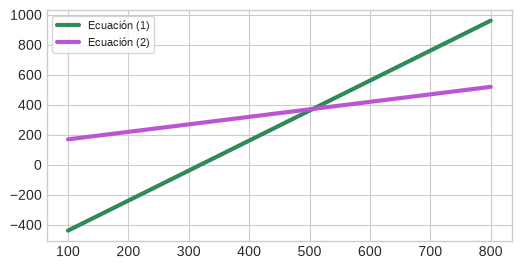

In [2]:
# Dominio
x = np.linspace(100,800,11)

# Línea recta 1
m1 = 2
b1 = -638.89
y1 = m1 * x + b1 # Evaluación

# Línea recta 2
m2 = 1/2.
b2 = 119.44
y2 = m2 * x + b2 # Evaluación

print(f"x = {x}\n")
print(f"m1 = {m1}")
print(f"b1 = {b1}")
print(f"y1 = {y1}\n")

print(f"m2 = {m2}")
print(f"b2 = {b2}")
print(f"y2 = {y2}")

# Graficamos las rectas
plt.figure(figsize=(6,3))
plt.plot(x, y1, lw = 3, c = "seagreen", label = "Ecuación (1)") # Línea recta 1
plt.plot(x, y2, lw = 3, c = "mediumorchid", label = "Ecuación (2)") # Línea recta 2
plt.legend(ncol = 1, frameon=True, loc="best", fontsize=8)
plt.grid(True)
plt.show()

<div class="alert alert-success">

**Pregunta**. ¿Qué representa el punto donde las rectas se cruzan?

</div>

<div class="alert alert-info">

## Ejemplo 2.

El sistema lineal $(1)$ definido en el planteamiento inicial de esta notebook, proviene de la aplicación del método de diferencias finitas a la ecuación de calor en una dimensión, en donde se usan los siguientes parámetros físicos:

- $\kappa = 0.5$ [W /m $^o$C]
- $L = 0.02$ [m]
- $T_A = 100$ [$^o$C]
- $T_B = 200$ [$^o$C]
- $q = 5 \times 10^6$ [W/m$^3$]  (Flujo de calor)
- $N = 2$ (número de nodos)

La función `dfsol.sistema_lineal()`, definida en el archivo [`dfsol.py`](dfsol.py), crea la matriz del sistema, el RHS y los regresa. 

1. Utilizaremos esta función para almacenar la matriz en el arreglo `A` y el RHS en el arreglo `b` usando los datos antes descritos.

**Nota**. Observa que al principio de esta notebook se incluyeron las bibliotecas que se usarán, particularmente: `import dfsol` que incluye varias funciones que serán usadas en los ejemplos siguientes.

</div>


In [3]:
# Definimos los parámetros físicos del problema
k = 1000
L = 0.5
TA = 500
TB = 100
q = 5e+6
N = 2

# Calculamos la matriz y el RHS del sistema
A, b = dfsol.sistema_lineal(TA, TB, q, L, k, N)

print(f"Matriz del sistema: \n{A}")
print(f"RHS: \n{b}")

Matriz del sistema: 
[[ 2. -1.]
 [-1.  2.]]
RHS: 
[638.88888889 238.88888889]


<div class="alert alert-info">

2. Resolvemos ahora el sistema con la función [`np.linalg.solve()`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) y almacenamos la solución en el arreglo `sol`.

</div>

In [4]:
sol = np.linalg.solve(A,b) # Función del módulo linalg para resolver el sistema

print(f"Solución del sistema: \n{sol}")

Solución del sistema: 
[505.55555556 372.22222222]


<div class="alert alert-info">

3. Realizamos las gráficas de las líneas rectas y de la solución.

</div>


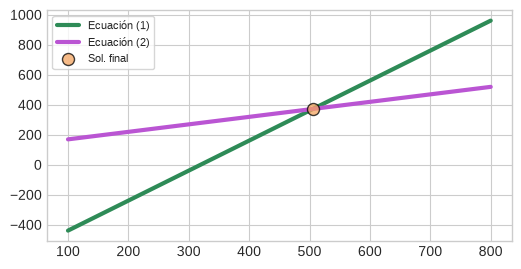

In [5]:
# Graficamos las rectas y la solución
plt.figure(figsize=(6,3))
plt.plot(x, y1, lw = 3, c = "seagreen", label = "Ecuación (1)") # Línea recta 1
plt.plot(x, y2, lw = 3, c = "mediumorchid", label = "Ecuación (2)") # Línea recta 2
plt.scatter(sol[0], sol[1], fc="sandybrown", ec="black", s = 75, alpha=0.75, 
            zorder=5, label='Sol. final') # Solución
plt.legend(ncol = 1, frameon=True, loc="best", fontsize=8)
plt.grid(True)
plt.show()

<div class="alert alert-info">

**Nota**. Con esta gráfica ya sabes lo que representa el punto donde se cruzan las rectas.

</div>

# Descripción del método de Gauss-Seidel.

Tomando como base el sistema de ecuaciones lineales de $2 \times 2$ de los ejemplos anteriores, podemos escribirlo de la siguiente manera: 

$$
\begin{array}{ccccccc}
a_{11}u_1 & + & a_{12}u_2 & = & b_1 \\
a_{21}u_1 & + & a_{22}u_2 & = & b_2 \\
\end{array}
$$

donde $a_{ij}$ con $i,j = 1, 2$ son los coeficientes de la matriz del sistema, $(u_1, u_2)$ son las incógnitas y $(b_1, b_2)$ es el lado derecho (RHS) del sistema.

Supongamos que tenemos una solución inicial aproximada $\mathbf{u}^0 = (u_1^0, u_2^0)$. Usando esta solución inicial, despejamos $u_1$ de la primera ecuación y calculamos $\textcolor{blue}{u_1^1}$. Luego despejamos $u_2$ de la segunda ecuación pero usamos el valor $\textcolor{blue}{u_1^1}$ que acabamos de calcular para obtener $u_2^1$; esto lo escribimos como sigue:

$$
\begin{eqnarray*}
	\textcolor{blue}{u_1^1} & = & \dfrac{1}{a_{11}} \left( b_1 - (a_{12}u_2^0) \right) \\
	u_2^1 & = & \dfrac{1}{a_{22}} \left( b_2 - (a_{21}\textcolor{blue}{u_1^1}) \right)  \\
\end{eqnarray*}
$$

Siguiendo esta lógica, se puede realizar una segunda iteración, para calcular una segunda aproximación a la solución, que sería:

$$
\begin{eqnarray*}
	\textcolor{blue}{u_1^2} & = & \dfrac{1}{a_{11}} \left( b_1 - (a_{12}u_2^1) \right) \\
	u_2^2 & = & \dfrac{1}{a_{22}} \left( b_2 - (a_{21}\textcolor{blue}{u_1^2}) \right)  \\
\end{eqnarray*}
$$

Si nuesto sistema fuera de $n \times n$ y nos encontramos en la iteración $k$-ésima, y si además ya hemos evaluado $\textcolor{blue}{u_1^{k}}$ y $\textcolor{blue}{u_2^{k}}$, entonces para evaluar $u_3^k$ haríamos lo siguiente:

$$
\begin{eqnarray*}
\textcolor{blue}{u_1^{k}} & = &\left( b_1 - (a_{12}u_2^{k-1} + a_{13} u_3^{k-1} + \dots  + a_{1n}u_n^{k-1}) \right) / a_{11}  \\
\textcolor{blue}{u_2^{k}} & = &\left( b_2 - (a_{21}\textcolor{blue}{u_1^{k}} + a_{23}u_3^{k-1} + \dots  + a_{2n}u_n^{k-1}) \right) / a_{22} \\
u_3^{k} & = &\left( b_3 - (a_{31}\textcolor{blue}{u_1^{k}} + a_{32}\textcolor{blue}{u_2^{k}} + \dots  + a_{3n}u_n^{k-1})\right) / a_{22}
\end{eqnarray*}
$$

Una fórmula general para este método es como sigue:

$$
u_i^k = \frac{1}{a_{i,i}} \left(b_i -  \sum_{j < i} a_{i,j} \textcolor{blue}{u_j^{k}} - \sum_{j > i} a_{i,j} u_j^{k-1} \right) 
$$   

que es válida para $i = 1, \dots, n$ y $k = 1, 2, \dots$.

Observa que es importante el orden en que se evalúan las ecuaciones.

Para saber cuándo terminar con estas iteraciones, cálculamos el diferencia entre iteraciones, que se escribe como sigue:

$$
E^k = || (u_1, u_2)^k - (u_1, u_2)^{k-1}|| = || \mathbf{u}^k - \mathbf{u}^{k-1}|| \tag{3}
$$

El valor de $E^k$ debería disminuir en cada iteración, entonces podemos establecer una tolerancia, de tal manera que cuando $E^k$ sea menor a esa tolerancia entonces podemos terminar el proceso y quedarnos con $(u_1, u_2)^k$ cómo la última aproximación a la solución.

## Algoritmo.
En general podemos definir el siguiente algoritmo para el método de Gauss-Seidel.

<center>
<img src="./algo_GS.png"  width='500px'/>
</center>

**Observaciones.**

* En este algoritmo hay un ciclo `while` el cual termina cuando el error es menor o igual que una tolerancia (`tol`) o se ha alcanzado un número máximo de iteraciones (`kmax`).
* En la línea **13** se calcula la diferencia entre iteraciones consecutivas, que en términos matemáticos se define como $E = || \mathbf{u}^k - \mathbf{u}^{k-1}||$. A esta diferencia también se le conoce como error.
  
## Implementación.

En la siguiente celda se implementa el algoritmo de Gauss-Seidel. Revisa la implementación y comparala con el algoritmo. Ejecuta la celda para definir la función `gauss-seidel()`.

In [6]:
def gauss_seidel(A, b, tol, kmax, ui):
    N = len(b)
    unew = np.zeros(N)

    # Solución inicial
    uold = np.copy(ui)

    # Listas para los pasos intermedios y el error
    xs = [uold[0]]
    ys = [uold[1]]

    # Error  
    E = 10 # mayor que la tolerancia
    E_lista = [] # Lista para los errores
    
    print("{:^2} {:^10} {:^12} {:^12}".format(" i ", "Error", "u1", "u2"))
        
    k = 0
    while E > tol and k < kmax:
        for i in range(0,N):
            unew[i] = 0
            for j in range(0,i):
                unew[i] += A[i,j] * unew[j] # Se usa información actualizada
            for j in range(i+1,N):
                unew[i] += A[i,j] * uold[j]                
            unew[i] = (b[i] - unew[i]) / A[i,i]

        # Calculamos el error con respecto a la iter anterior
        E = np.linalg.norm(unew - uold)

        # Almacenamos los pasos y el error en las listas
        xs.append(unew[0])
        ys.append(unew[1])
        E_lista.append(E)
        
        # Incrementamos k y actualizamos xold
        k += 1
        uold = np.copy(unew)
        
        print("{:2d} {:10.9f} ({:10.9f}, {:10.9f})".format(k, E, unew[0], unew[1]))
    return unew, xs, ys, E_lista, k

Observa que la función `gauss_seidel()` regresa 5 valores: 

* `unew` la solución obtenida, 
* `xs` y `ys` componentes de las soluciones aproximadas en cada paso, 
* `E_lista` una lista con el error para cada iteración.
* `k` el número total de iteraciones realizadas.

<div class="alert alert-info">

## Ejemplo 3.

Haciendo uso de la función `gauss_seidel()` definida en la celda anterior, aproximaremos la solución del sistema de ecuaciones definido en el **Ejemplo 2**, utilizando los siguientes datos:

* Solución inicial `ui` = $(100, 100)$.
* Tolerancia `tol` = $1 \times 10^{-5}$.
* Número máximo de iteraciones `kmax` = $50$.

Posteriormente se realizan algunas gráficas.

</div>

 i    Error         u1           u2     
 1 338.059663994 (369.444444444, 304.166666667)
 2 114.132636352 (471.527777778, 355.208333333)
 3 28.533159088 (497.048611111, 367.968750000)
 4 7.133289772 (503.428819444, 371.158854167)
 5 1.783322443 (505.023871528, 371.956380208)
 6 0.445830611 (505.422634549, 372.155761719)
 7 0.111457653 (505.522325304, 372.205607096)
 8 0.027864413 (505.547247993, 372.218068441)
 9 0.006966103 (505.553478665, 372.221183777)
10 0.001741526 (505.555036333, 372.221962611)
11 0.000435381 (505.555425750, 372.222157319)
12 0.000108845 (505.555523104, 372.222205997)
13 0.000027211 (505.555547443, 372.222218166)
14 0.000006803 (505.555553527, 372.222221208)


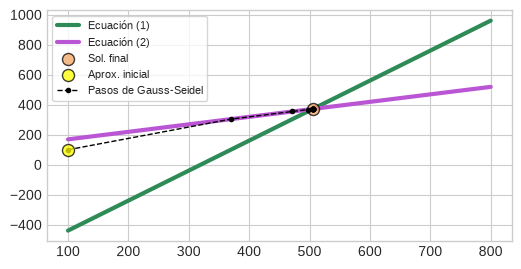

In [7]:
ui = np.array([100, 100])
tol = 1e-5
kmax = 50

# Método de Gauss-Seidel
solG, xs, ys, error, it = gauss_seidel(A, b, tol, kmax, ui)

# Graficamos las rectas, la solución y los pasos.
plt.figure(figsize=(6,3))
plt.plot(x, y1, lw = 3, c = "seagreen", label = "Ecuación (1)") # Línea recta 1
plt.plot(x, y2, lw = 3, c = "mediumorchid", label = "Ecuación (2)") # Línea recta 2
plt.scatter(sol[0], sol[1], fc="sandybrown", ec="black", s = 75, alpha=0.75, 
            zorder=5, label='Sol. final') # Solución

# Graficamos los pasos
plt.scatter(xs[0], ys[0], fc="yellow", ec="black", s = 75, alpha=0.75, 
            zorder=8, label="Aprox. inicial")
plt.plot(xs, ys, c="black", marker = ".", ls = "--", lw=1.0, 
         zorder=7, label="Pasos de Gauss-Seidel")

plt.legend(ncol = 1, frameon=True, loc="best", fontsize=8)
plt.grid(True)
plt.show()

<div class="alert alert-success">

**Pregunta**.
¿Qué crees que pasará si cambiamos la solución inicial (punto amarillo)?

</div>

<div class="alert alert-info">

Graficamos el error que se va obteniendo en cada paso del algoritmo.
</div>

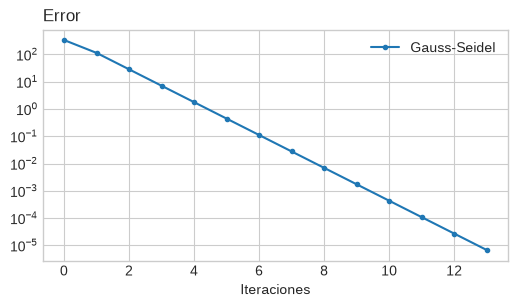

In [8]:
# Gráfica del error
plt.figure(figsize=(6,3))
plt.title("Error", loc="left")
plt.plot(list(range(0,it)), error, marker=".", label="Gauss-Seidel")
plt.xlabel("Iteraciones")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert alert-info">

**Nota**. Observa que efectivamente el error va disminuyendo conforme avanzamos en las iteraciones hasta alcanzar la tolerancia impuesta.

</div>

<div class="alert alert-success">

**Pregunta**.
¿Que crees que pasará si cambiamos el valor de la tolerancia (`tol`)?

</div>

Almacenamos el error en el archivo `zd_errorGaussSeidel.npy` y los pasos en el archivo `zd_pasosGaussSeidel.npy`.

In [9]:
dir_data = Path("datos")
dir_data.mkdir(parents=True, exist_ok=True)

np.save("./datos/zd_errorGaussSeidel.npy", error)
np.save("./datos/zd_pasosGaussSeidel.npy", np.array([xs,ys]))

Checamos que se pueden leer los archivos con la función `np.load()`:

In [10]:
print("Error Gauss-Seidel = \n{}\n".format(np.load("./datos/zd_errorGaussSeidel.npy")))
print("(xs, ys) = \n{}\n".format(np.load("./datos/zd_pasosGaussSeidel.npy")))

Error Gauss-Seidel = 
[3.38059664e+02 1.14132636e+02 2.85331591e+01 7.13328977e+00
 1.78332244e+00 4.45830611e-01 1.11457653e-01 2.78644132e-02
 6.96610329e-03 1.74152582e-03 4.35381456e-04 1.08845364e-04
 2.72113410e-05 6.80283529e-06]

(xs, ys) = 
[[100.         369.44444444 471.52777778 497.04861111 503.42881944
  505.02387153 505.42263455 505.5223253  505.54724799 505.55347866
  505.55503633 505.55542575 505.5555231  505.55554744 505.55555353]
 [100.         304.16666667 355.20833333 367.96875    371.15885417
  371.95638021 372.15576172 372.2056071  372.21806844 372.22118378
  372.22196261 372.22215732 372.222206   372.22221817 372.22222121]]

